In [2]:
# Install QuTiP and dependencies in Colab
!pip install qutip matplotlib numpy -q
print("Libraries installed successfully!")

Libraries installed successfully!


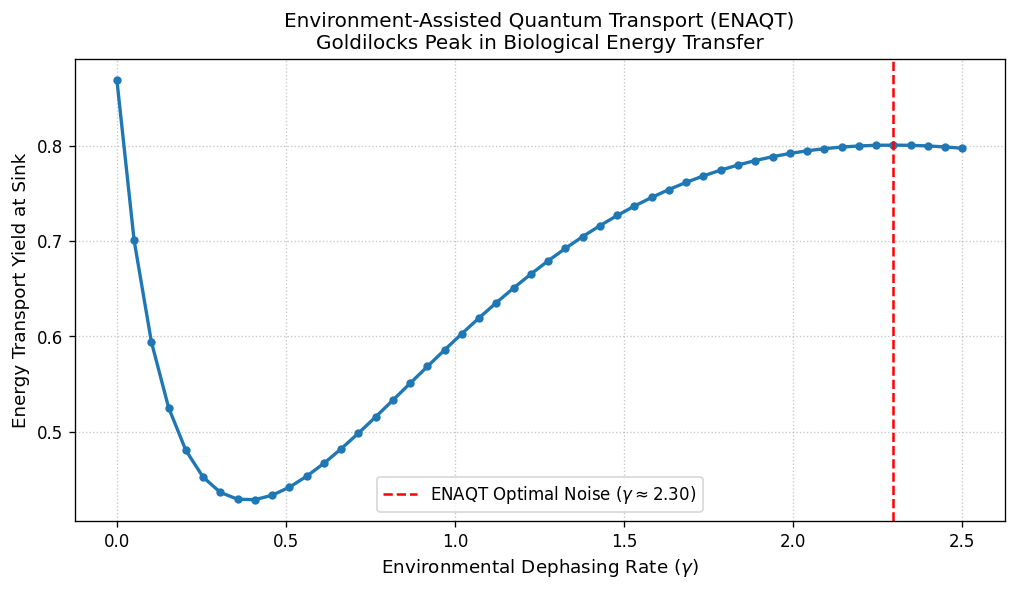

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, mesolve, Qobj

# ---------------------------------------------------------
# 1. Setup Biological System with Stronger Barrier
# ---------------------------------------------------------
N = 3

# Higher barrier (E1 = 3.5) suppresses coherent tunneling at gamma = 0
E = [1.0, 3.5, 1.0]
J = 0.2

H_mat = np.zeros((N, N))
for i in range(N):
    H_mat[i, i] = E[i]
    if i < N - 1:
        H_mat[i, i + 1] = J
        H_mat[i + 1, i] = J

H = Qobj(H_mat)

psi0 = basis(N, 0)
tlist = np.linspace(0, 50, 500)

# ---------------------------------------------------------
# 2. Sink and Dephasing Setup
# ---------------------------------------------------------
gamma_sink = 0.3
sink_op = np.sqrt(gamma_sink) * basis(N, 2) * basis(N, 2).dag()

def calculate_efficiency(dephasing_rate):
    c_ops = [sink_op]

    if dephasing_rate > 0:
        for i in range(N):
            site_op = basis(N, i) * basis(N, i).dag()
            c_ops.append(np.sqrt(dephasing_rate) * site_op)

    e_ops = [basis(N, 2) * basis(N, 2).dag()]
    result = mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=e_ops)

    integrated_yield = np.trapezoid(result.expect[0], tlist) * gamma_sink
    return integrated_yield

# ---------------------------------------------------------
# 3. Sweep Noise Rates & Find ENAQT Peak
# ---------------------------------------------------------
gamma_range = np.linspace(0.001, 2.5, 50)
efficiencies = np.array([calculate_efficiency(g) for g in gamma_range])

# Ignore gamma = 0 edge artifact to find the true ENAQT noise-assisted peak
search_mask = gamma_range > 0.2
optimal_idx = np.argmax(efficiencies[search_mask])
optimal_gamma = gamma_range[search_mask][optimal_idx]
optimal_yield = efficiencies[search_mask][optimal_idx]

# Plotting
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(gamma_range, efficiencies, 'o-', color='#1f77b4', linewidth=2, markersize=4)

# Highlight the ENAQT Peak
plt.axvline(x=optimal_gamma, color='red', linestyle='--',
            label=fr'ENAQT Optimal Noise ($\gamma \approx {optimal_gamma:.2f}$)')

plt.title('Environment-Assisted Quantum Transport (ENAQT)\nGoldilocks Peak in Biological Energy Transfer', fontsize=12)
plt.xlabel(r'Environmental Dephasing Rate ($\gamma$)', fontsize=11)
plt.ylabel('Energy Transport Yield at Sink', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()